In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [49]:
latitude, longitude = np.loadtxt("input/cap_prov_ita.dat", unpack=True)
city_names = np.loadtxt("input/prov_ita.txt", dtype=str, usecols=0)

In [50]:
city_names

array(['Agrigento', 'Alessandria', 'Ancona', 'Aosta', 'Arezzo', 'Ascoli',
       'Asti', 'Avellino', 'Bari', 'Barletta-Andria-Trani', 'Belluno',
       'Benevento', 'Bergamo', 'Biella', 'Bologna', 'Bolzano', 'Brescia',
       'Brindisi', 'Cagliari', 'Caltanissetta', 'Campobasso',
       'Carbonia-Iglesias', 'Caserta', 'Catania', 'Catanzaro', 'Chieti',
       'Como', 'Cosenza', 'Cremona', 'Crotone', 'Cuneo', 'Enna', 'Fermo',
       'Ferrara', 'Firenze', 'Foggia', 'Forlì-Cesena', 'Frosinone',
       'Genova', 'Gorizia', 'Grosseto', 'Imperia', 'Isernia', 'La',
       "L'Aquila", 'Latina', 'Lecce', 'Lecco', 'Livorno', 'Lodi', 'Lucca',
       'Macerata', 'Mantova', 'Massa-Carrara', 'Matera', 'Messina',
       'Milano', 'Modena', 'Monza', 'Napoli', 'Novara', 'Nuoro',
       'Olbia-Tempio', 'Oristano', 'Padova', 'Palermo', 'Parma', 'Pavia',
       'Perugia', 'Pesaro', 'Pescara', 'Piacenza', 'Pisa', 'Pistoia',
       'Pordenone', 'Potenza', 'Prato', 'Ragusa', 'Ravenna', 'Reggio',
       'Reggi

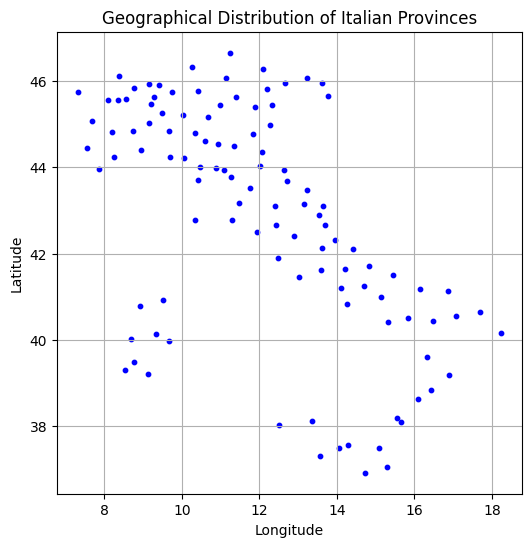

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(latitude, longitude, c='blue', marker='o', s=10)
plt.title("Geographical Distribution of Italian Provinces")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()

In [52]:
df = pd.read_csv("outputs/poplog_N110_Pop1500_Gen1000_Italy.dat", sep=r'\s+', comment='#')
df

,Generation,Rank,Fitness,City_1,City_2,City_3,City_4,City_5,City_6,City_7,...,City_102,City_103,City_104,City_105,City_106,City_107,City_108,City_109,City_110,City_111
0,0,0,427.798,1,99,17,58,50,65,94,...,87,56,49,67,22,72,100,27,5,1
1,0,1,441.799,1,93,19,52,34,49,3,...,91,85,74,14,39,106,103,109,12,1
2,0,2,446.927,1,39,34,75,22,44,40,...,96,2,59,14,92,107,69,101,64,1
3,0,3,447.159,1,45,65,69,30,25,8,...,92,17,95,94,55,85,6,68,84,1
4,0,4,447.178,1,4,61,70,38,85,84,...,72,34,73,83,25,19,56,68,103,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501495,1000,1495,140.254,1,20,32,78,91,24,80,...,88,64,87,22,19,62,50,98,66,1
1501496,1000,1496,142.273,1,20,32,78,91,24,80,...,64,87,22,19,74,62,97,98,66,1
1501497,1000,1497,142.714,1,4,96,31,42,89,39,...,105,64,88,63,49,41,90,97,98,1
1501498,1000,1498,144.958,1,20,32,78,91,24,80,...,103,105,14,11,75,102,69,95,66,1


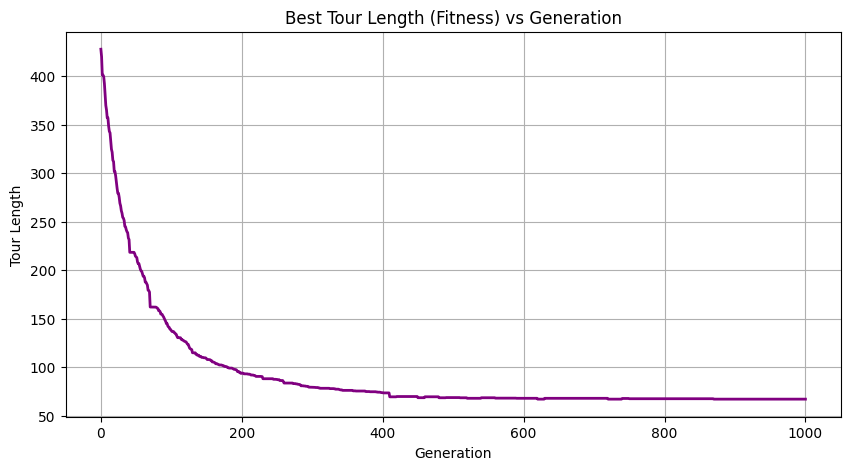

In [53]:
# ==========================================
# PLOT 1: FITNESS VS GENERATION
# ==========================================

# Since Rank 0 is always the best individual of the generation, we just filter for Rank == 0
best_fitness_df = df[df['Rank'] == 0]

plt.figure(figsize=(10, 5))
plt.plot(best_fitness_df['Generation'], best_fitness_df['Fitness'], color='purple', linewidth=2)
plt.title('Best Tour Length (Fitness) vs Generation')
plt.xlabel('Generation')
plt.ylabel('Tour Length')
plt.grid(True)
plt.show()

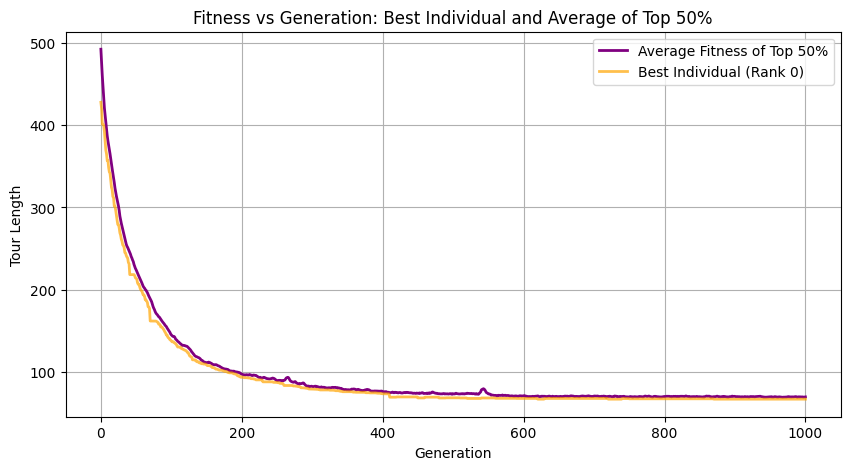

In [54]:
half_population = max(df['Rank'])/2.0
ave_fitness_best_half = df[df['Rank'] < half_population].groupby('Generation')['Fitness'].mean()

plt.figure(figsize=(10, 5))
plt.plot(ave_fitness_best_half.index, ave_fitness_best_half.values, color='purple', linewidth=2, label='Average Fitness of Top 50%')
plt.plot(best_fitness_df['Generation'], best_fitness_df['Fitness'], color='orange', linewidth=2, label='Best Individual (Rank 0)', alpha=0.7)
plt.title('Fitness vs Generation: Best Individual and Average of Top 50%')
plt.xlabel('Generation')
plt.ylabel('Tour Length')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# ==========================================
# PLOT 2: TOUR VISUALIZATIONS
# ==========================================

# A clean helper function so we don't copy-paste plotting code 3 times!
def plot_tour(generation_num, df, x_coord, y_coord):
    # Extract the row for the best individual of the requested generation
    # .iloc[0] safely grabs the first matching row as a Series
    best_row = df[(df['Generation'] == generation_num) & (df['Rank'] == 0)].iloc[0]
    
    # Extract just the city indices (skipping the first 3 columns: Gen, Rank, Fitness)
    tour = best_row[3:].values.astype(int)
    fitness = best_row['Fitness']
    
    plt.figure(figsize=(7, 7))
    plt.scatter(x_coord, y_coord, color='blue', s=5)
    
    # Plot the city numbers
    #for i in range(len(x_coord)):
    #    plt.text(x_coord[i], y_coord[i], str(i + 1), fontsize=12, ha='center', va='center', c="r")

    # Connect the cities with smaller, cleaner arrows
    for i in range(len(tour) - 1):
        city_a = tour[i] - 1      # -1 to convert 1-based city name to 0-based index
        city_b = tour[i + 1] - 1  
        
        # Calculate the vector differences
        dx = x_coord[city_b] - x_coord[city_a]
        dy = y_coord[city_b] - y_coord[city_a]
        
        plt.arrow(x_coord[city_a], y_coord[city_a], dx, dy,
                  head_width=0.03,        # Much smaller arrowhead width
                  head_length=0.05,       # Much shorter arrowhead length
                  fc='green', ec='green',
                  length_includes_head=True, # Prevents arrow from overshooting the number
                  alpha=0.7)                 # Slight transparency looks nicer
                  
    # Notice we REMOVED the redundant closure loop here!
    
    plt.title(f'Best Tour Visualization: Generation {generation_num}\nFitness: {fitness:.4f}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

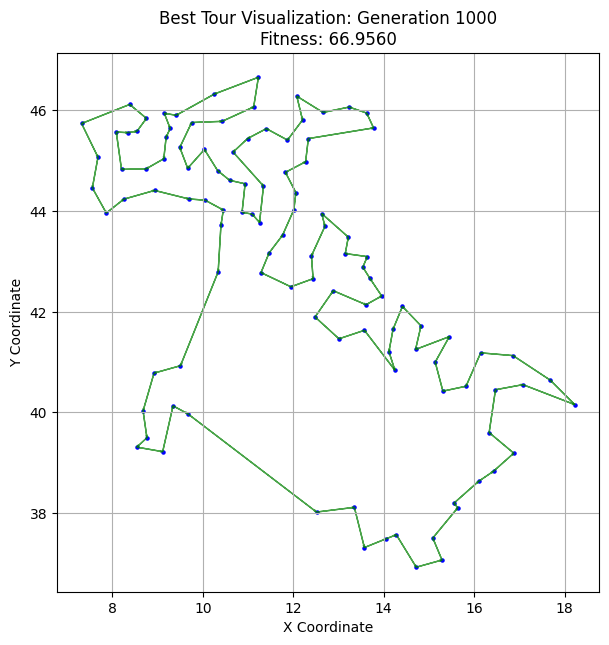

In [61]:
plot_tour(1000, df, latitude, longitude)   # Final result after all generations (last generation)